C:\Users\ATOMIQ\AppData\Local\Temp\ipykernel_196\4191408914.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["dh_utc"] = pd.to_datetime(df["dh_utc"], dayfirst=True)


Accuracy : 0.9681536874677669

Classification report :
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     21690
           1       0.71      0.90      0.79      1578

    accuracy                           0.97     23268
   macro avg       0.85      0.94      0.89     23268
weighted avg       0.97      0.97      0.97     23268


RMSE : 0.1610
MAE  : 0.0365


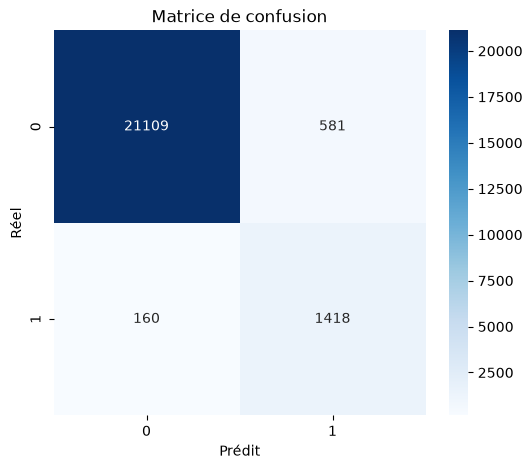

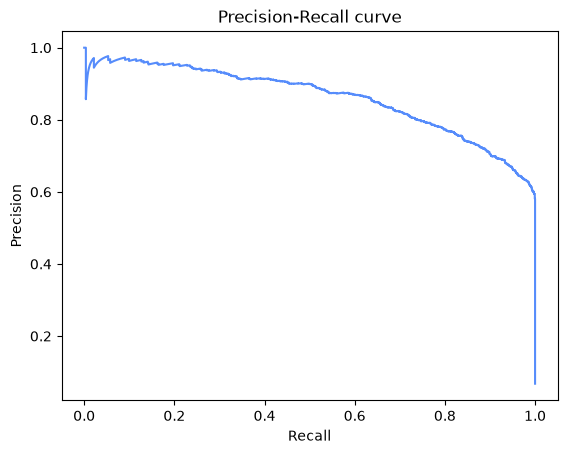

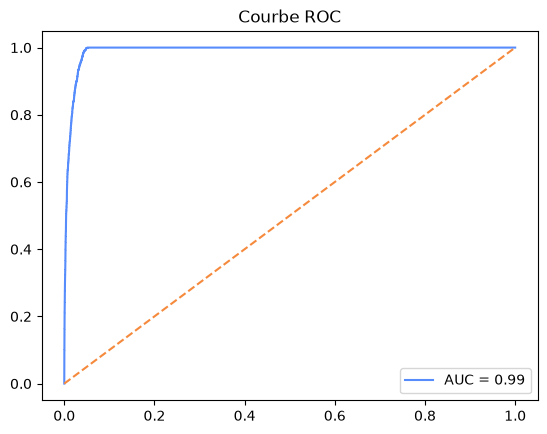

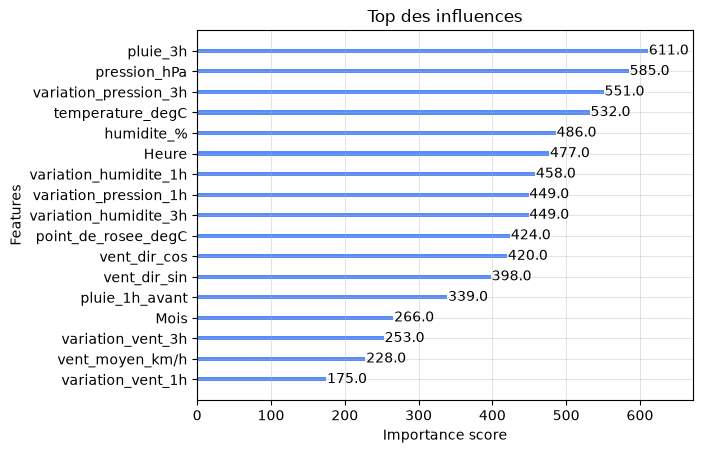

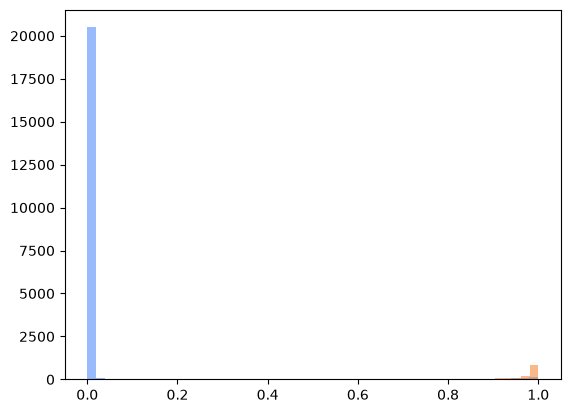

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    auc,
    mean_squared_error,
    mean_absolute_error
)

# Chargement du modèle préalablement entraîné.
# Ce modèle a été entraîné sur les données 2025 et partielles 2024 (métriques avec pluies).
model = xgb.XGBClassifier()
model.load_model("modele_prediction_pluie_V2.json")

# Chargement du jeu de données 2023.
# Ce dataset est totalement indépendant du jeu d'entraînement.
df = pd.read_csv("donnees_meteo_2023_NETTOYEES.csv", sep=";")

# Conserver de la colonne date en format exploitable :
df["dh_utc"] = pd.to_datetime(df["dh_utc"], dayfirst=True)

# Création des variables temporelles :
df["Mois"] = df["dh_utc"].dt.month
df["Heure"] = df["dh_utc"].dt.hour

# Création des variables :
df["variation_pression_3h"] = df["pression_hPa"] - df["pression_hPa"].shift(3)
df["variation_humidite_3h"] = df["humidite_%"] - df["humidite_%"].shift(3)
df["variation_vent_3h"] = df["vent_moyen_km/h"] - df["vent_moyen_km/h"].shift(3)
df["variation_pression_1h"] = df["pression_hPa"] - df["pression_hPa"].shift(1)
df["variation_humidite_1h"] = df["humidite_%"] - df["humidite_%"].shift(1)
df["variation_vent_1h"] = df["vent_moyen_km/h"] - df["vent_moyen_km/h"].shift(1)
# Historique pluie
df["pluie_1h_avant"] = df["pluie_1h_mm"].shift(1)
df["pluie_3h"] = df["pluie_1h_mm"].rolling(3).sum()
# Vent encodé
df["vent_dir_sin"] = np.sin(df["vent_direction_deg"] * np.pi / 180)
df["vent_dir_cos"] = np.cos(df["vent_direction_deg"] * np.pi / 180)

# Suppression des lignes contenant des valeurs manquantes :
df = df.dropna()

# On supprime les colonnes non pertinentes :
X = df.drop(columns=[
    "pleut_il", # variable cible
    "station_id",
    "dh_utc",
    "vent_direction_deg", # remplacée par sin/cos
    "pluie_1h_mm"
])

# Variable cible :
y = df["pleut_il"]

# Le seuil est volontairement ajusté à 0.65 pour mieux contrôler le compromis entre détection et faux positifs.
threshold = 0.65

# Calcul des probabilités de pluie :
y_proba = model.predict_proba(X)[:, 1]
y_pred = (y_proba > threshold).astype(int)

# Calcul des métriques principales :
print("Accuracy :", accuracy_score(y, y_pred))

# Rapport détaillé des performances :
print("\nClassification report :")
print(classification_report(y, y_pred))

#Calcul de nos indicateurs qualités :
rmse = np.sqrt(mean_squared_error(y, y_proba))
mae = mean_absolute_error(y, y_proba)

# afficher résultats :
print(f"\nRMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

# Matrice de confusion.
# Permet de visualiser les erreurs :
    # faux positifs
    # faux négatifs
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# Courbe Precision-Recal :
precision, recall, _ = precision_recall_curve(y, y_proba)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.show()

# Permet d'évaluer la capacité du modèle à discriminer les classes :
fpr, tpr, _ = roc_curve(y, y_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], "--")
plt.legend()
plt.title("Courbe ROC")
plt.show()

# Permet d'identifier les facteurs les plus influents dans la prédiction :
xgb.plot_importance(model)
plt.title("Top des influences")
plt.show()

# Analyse de la distribution des probabilités :
plt.hist(y_proba[y==0], bins=50, alpha=0.6)
plt.hist(y_proba[y==1], bins=50, alpha=0.6)
plt.show()
